In [1]:
# Pandas and numpy for data manipulation
import pandas as pd
import numpy as np
# No warnings about setting value on copy of slice
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', 60)
# Matplotlib for visualization
import matplotlib.pyplot as plt
%matplotlib inline
# Set default font size
plt.rcParams['font.size'] = 24
from IPython.core.pylabtools import figsize
# Seaborn for visualization
import seaborn as sns
sns.set(font_scale = 2)
# Imputing missing values and scaling values
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [2]:
# Read in data into dataframes
train_features = pd.read_csv('training_features.csv')
test_features = pd.read_csv('testing_features.csv')
train_labels = pd.read_csv('training_labels.csv')
test_labels = pd.read_csv('testing_labels.csv')
# Display sizes of data
print('Training Feature Size: ', train_features.shape)
print('Testing Feature Size: ', test_features.shape)
print('Training Labels Size: ', train_labels.shape)
print('Testing Labels Size: ', test_labels.shape)
train_features.head(12)

Training Feature Size:  (7674, 7)
Testing Feature Size:  (2303, 7)
Training Labels Size:  (7674, 1)
Testing Labels Size:  (2303, 1)


,PT08.S1(CO),T,RH,log_AH,hour,month,Datetime
0,1360.0,13.6,48.9,-0.277336,18.0,3.0,2004-03-10 18:00:00
1,1292.0,13.3,47.7,-0.320894,19.0,3.0,2004-03-10 19:00:00
2,1402.0,11.9,54.0,-0.287415,20.0,3.0,2004-03-10 20:00:00
3,1376.0,11.0,60.0,-0.239908,21.0,3.0,2004-03-10 21:00:00
4,1272.0,11.2,59.6,-0.237242,22.0,3.0,2004-03-10 22:00:00
5,1197.0,11.2,59.2,-0.242326,23.0,3.0,2004-03-10 23:00:00
6,1185.0,11.3,56.8,-0.274042,0.0,3.0,2004-03-11 00:00:00
7,1136.0,10.7,60.0,-0.261105,1.0,3.0,2004-03-11 01:00:00
8,1094.0,10.7,59.7,-0.268141,2.0,3.0,2004-03-11 02:00:00
9,1010.0,10.3,60.2,-0.285418,3.0,3.0,2004-03-11 03:00:00


In [3]:
if 'Datetime' in train_features.columns:
    train_features = train_features.drop(columns=['Datetime'])
if 'Datetime' in test_features.columns:
    test_features = test_features.drop(columns=['Datetime'])

In [4]:
# Create an imputer object with a median filling strategy
imputer = SimpleImputer(strategy='median')
# Train on the training features
imputer.fit(train_features)
# Transform both training data and testing data
X = imputer.transform(train_features)
X_test = imputer.transform(test_features)
print('Missing values in training features: ', np.sum(np.isnan(X)))
print('Missing values in testing features: ', np.sum(np.isnan(X_test)))
# Make sure all values are finite
print(np.where(~np.isfinite(X)))
print(np.where(~np.isfinite(X_test)))

Missing values in training features:  0
Missing values in testing features:  0
(array([], dtype=int64), array([], dtype=int64))
(array([], dtype=int64), array([], dtype=int64))


In [5]:
# Create the scaler object with a range of 0-1
scaler = MinMaxScaler(feature_range=(0, 1))
# Fit on the training data
scaler.fit(X)
# Transform both the training and testing data
X = scaler.transform(X)
X_test = scaler.transform(X_test)
# Convert y to one-dimensional array (vector)
y = np.array(train_labels).reshape((-1, ))
y_test = np.array(test_labels).reshape((-1, ))

In [6]:
# Function to calculate mean absolute error
def mae(y_true, y_pred):
 return np.mean(abs(y_true - y_pred))

In [7]:
# Takes in a model, trains the model, and evaluates the model on the test set
def fit_and_evaluate(model):
 # Train the model
    model.fit(X, y)

 # Make predictions and evaluate
    model_pred = model.predict(X_test)
    model_mae = mae(y_test, model_pred)

 # Return the performance metric
    return model_mae

In [8]:
# Initialise the Support Vector Regression (SVR) model with specific hyperparameters
svm = SVR(C = 1000, gamma = 0.1)
svm_mae = fit_and_evaluate(svm)
#Output the final precision of the SVR model on the unseen test set
print('Support Vector Machine Regression Performance on the test set: MAE = %0.4f' % svm_mae)

Support Vector Machine Regression Performance on the test set: MAE = 0.4745


In [9]:
# Initialise the Random Forest Regressor model
random_forest = RandomForestRegressor(random_state=60)
random_forest_mae = fit_and_evaluate(random_forest)
#Output the final precision of the random forest model on the unseen test set
print('Random Forest Regression Performance on the test set: MAE = %0.4f' %
random_forest_mae)

Random Forest Regression Performance on the test set: MAE = 0.1842


In [10]:
best_model = RandomForestRegressor()
best_model.fit(train_features, train_labels.values.ravel())

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# Generate CO concentration forecasts using the trained Random Forest model
predictions = best_model.predict(test_features)

In [12]:
# Define our thresholds
WHO_LIMIT = 10.0      # The official "Danger" zone
LOCAL_SPIKE = 4.5     # The "High Traffic/Industrial" zone (90th percentile)
conditions = [
    (predictions >= WHO_LIMIT),
    (predictions >= LOCAL_SPIKE) & (predictions < WHO_LIMIT),
    (predictions < LOCAL_SPIKE)
]

choices = [
    "UNSAFE - Health Risk (Exceeds WHO)", 
    "CAUTION - High Local Pollution", 
    "SAFE - Good Air Quality"
]

results = pd.DataFrame({
    "Predicted_CO (mg/m³)": predictions,
    "Status": np.select(conditions, choices, default="Unknown")
})

print(results.head(10))



   Predicted_CO (mg/m³)                   Status
0              2.037000  SAFE - Good Air Quality
1              2.262000  SAFE - Good Air Quality
2              2.155000  SAFE - Good Air Quality
3              2.161000  SAFE - Good Air Quality
4              2.234000  SAFE - Good Air Quality
5              2.717000  SAFE - Good Air Quality
6              3.068667  SAFE - Good Air Quality
7              3.509000  SAFE - Good Air Quality
8              4.172730  SAFE - Good Air Quality
9              3.607000  SAFE - Good Air Quality


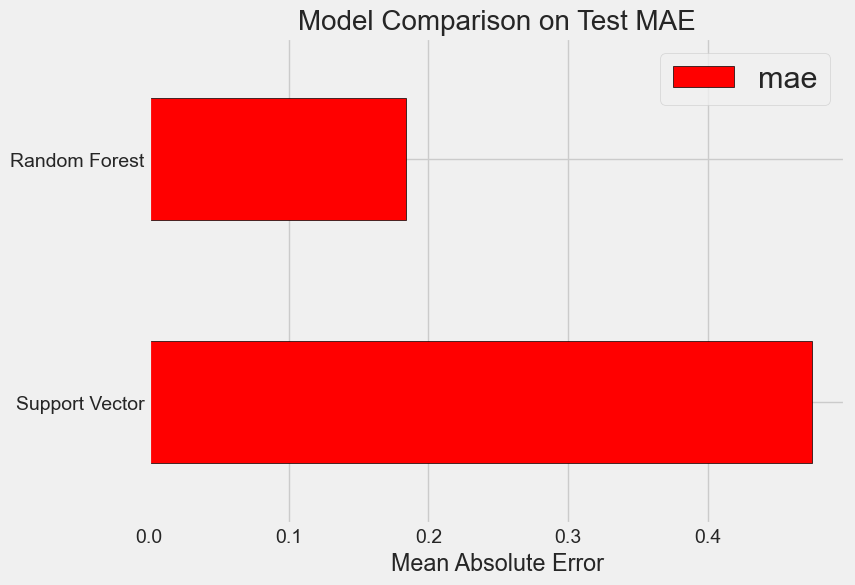

In [13]:
plt.style.use('fivethirtyeight')
figsize(8, 6)
# Dataframe to hold the results
model_comparison = pd.DataFrame({'model': ['Support Vector','Random Forest'],
 'mae': [svm_mae, random_forest_mae]})
# Horizontal bar chart of test mae
model_comparison.sort_values('mae', ascending = False).plot(x = 'model', y = 'mae', kind ='barh', color = 'red', edgecolor = 'black')
# Plot formatting
plt.ylabel(''); plt.yticks(size = 14); plt.xlabel('Mean Absolute Error'); plt.xticks(size = 14)
plt.title('Model Comparison on Test MAE', size = 20);
plt.show()

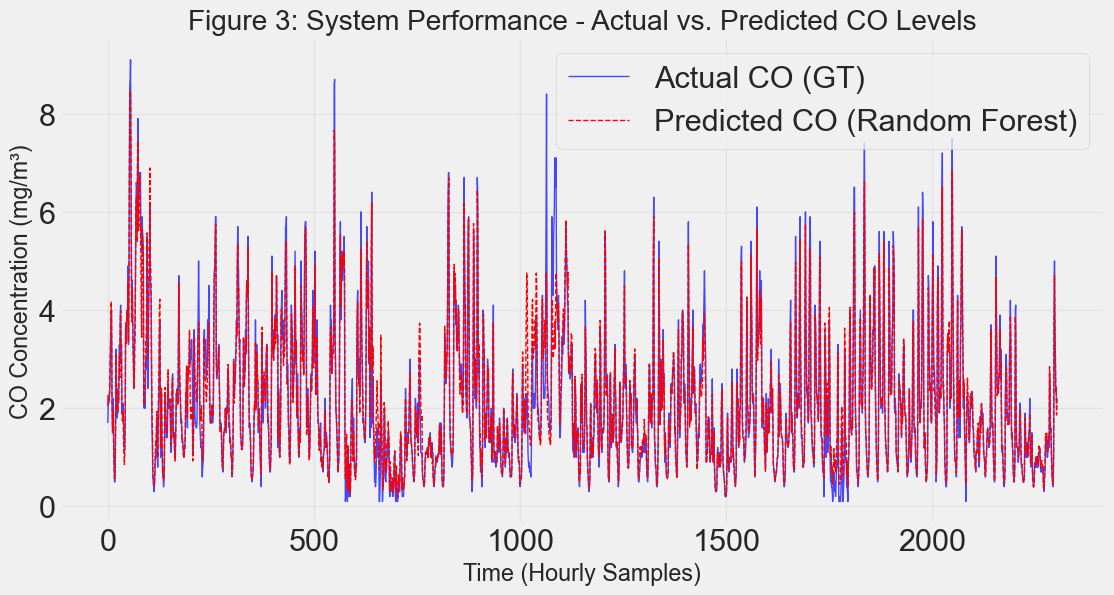

In [14]:
import matplotlib.pyplot as plt

#Set the plot size for readability
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual CO (GT)', color='blue', linewidth=1, alpha=0.7)

# Plot Predicted values from  best model
plt.plot(predictions, label='Predicted CO (Random Forest)', color='red', linestyle='--', linewidth=1)
plt.title('Figure 3: System Performance - Actual vs. Predicted CO Levels')
plt.xlabel('Time (Hourly Samples)')
plt.ylabel('CO Concentration (mg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)

#  Show the plot
plt.show()


In [19]:

# Combine features and labels for the training set
train_combined = pd.concat([train_features, train_labels], axis=1)
# Combine features and labels for the testing set
test_combined = pd.concat([test_features, test_labels], axis=1)
# Join them into one final "Processed Dataset" 
final_export = pd.concat([train_combined, test_combined])
# Save to CSV 
final_export.to_csv("processed_air_quality_data.csv", index=False)
print("\nSuccess: 'processed_air_quality_data.csv' has been generated.")



Success: 'processed_air_quality_data.csv' has been generated.
